In [11]:
import json, os, re, glob, itertools
import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.patches import Patch, Rectangle

RUNS_DIR = os.path.abspath(os.path.join(os.getcwd(), "..", "runs"))
assert os.path.isdir(RUNS_DIR), RUNS_DIR

# --- palette ---------------------------------------------------------------
# Colours come from a validated categorical set; each chart uses one encoding
# only, and every chart with >= 2 colours carries a legend, so blue never means
# two things in the same figure.
SURFACE, INK, SECOND, MUTED, GRID, AXIS = (
    "#fcfcfb", "#0b0b0b", "#52514e", "#898781", "#e1e0d9", "#c3c2b7")

PHASE_COLOR = {"PROGRESSING": "#2a78d6", "STUCK": "#eb6834", "COMPLETED": "#1baf7a"}
PHASES = ["PROGRESSING", "STUCK", "COMPLETED"]

# baseline -> limited -> broken, ordered by how degraded the search is
COND_ORDER = ["baseline", "limited", "broken"]
COND_COLOR = {"baseline": "#2a78d6", "limited": "#4a3aa7", "broken": "#e34948"}

MODEL_ORDER = ["gpt-5-nano", "gpt-5.6-luna", "gpt-5.6-terra"]
MODEL_COLOR = dict(zip(MODEL_ORDER, ["#2a78d6", "#eb6834", "#1baf7a"]))

# input -> visible output -> reasoning is an ordered ramp, so one hue, light to dark
TOKEN_COLOR = {"input": "#86b6ef", "visible_output": "#3987e5", "reasoning": "#184f95"}

mpl.rcParams.update({
    "figure.facecolor": SURFACE, "axes.facecolor": SURFACE,
    "savefig.facecolor": SURFACE,
    "axes.edgecolor": AXIS, "axes.labelcolor": SECOND, "text.color": INK,
    "xtick.color": MUTED, "ytick.color": MUTED,
    "axes.spines.top": False, "axes.spines.right": False,
    "grid.color": GRID, "grid.linewidth": 0.8,
    "font.size": 10, "axes.titlesize": 11, "axes.titleweight": "bold",
    "figure.dpi": 110, "lines.linewidth": 2,
})

def tidy(ax, grid_axis="y"):
    ax.grid(True, axis=grid_axis, zorder=0)
    ax.set_axisbelow(True)
    return ax

def short(run):
    # batch1-2-limited-gpt-5-nano-... -> b1-2 limited
    b, t, cond = run.split("-")[0], run.split("-")[1], run.split("-")[2]
    return f"{b.replace('batch', 'b')}-{t} {cond}"

In [12]:
# --- parsing ---------------------------------------------------------------
MODELS = ["gpt-5.6-luna", "gpt-5.6-terra", "gpt-5-nano"]
CONDITIONS = ["baseline", "broken", "limited"]
EFFORTS = ["low", "medium", "high"]

# Model names contain both '-' and '.', so the middle of the run id is matched
# against the known model list rather than split on '-'.
_RUN_RE = re.compile(
    r"^batch(?P<batch>\d+)-(?P<trial>\d+)-(?P<condition>" + "|".join(CONDITIONS) + r")"
    r"-(?P<models>.+)-(?P<effort>" + "|".join(EFFORTS) + r")"
    r"-(?P<topos>topos|notopos)-(?P<date>\d{8})-(?P<time>\d{6})$")

def parse_run_id(name):
    m = _RUN_RE.match(name)
    if not m:
        raise ValueError(f"unparseable run id: {name}")
    mid = m.group("models")
    for agent in sorted(MODELS, key=len, reverse=True):
        if mid.startswith(agent + "-") and mid[len(agent) + 1:] in MODELS:
            monitor = mid[len(agent) + 1:]
            break
    else:
        raise ValueError(f"unparseable model pair: {mid}")
    return dict(run=name, batch=int(m.group("batch")), trial=int(m.group("trial")),
                condition=m.group("condition"), agent_model=agent,
                monitor_model=monitor, effort=m.group("effort"),
                topos=(m.group("topos") == "topos"),
                started=m.group("date") + "-" + m.group("time"))

# Search-failure language in the agent's own summary, hedging language in the
# monitor's justification, and on-topic-ness of a cited source.
FAIL_RE = re.compile(
    r"search error|\berrors?\b|timed? ?out|timeout|no results|no relevant|"
    r"irrelevant|unrelated|off-topic|failed to (?:fetch|retrieve)|"
    r"could not (?:fetch|retrieve|find)|404|blocked|unavailable", re.I)
HEDGE_RE = re.compile(
    r"limited progress|little progress|slow progress|repeat|repetiti|"
    r"no convergence|not converging|circular|loop(?:ing)?\b|redundan|"
    r"marginal|stalling|stagnat|diminishing", re.I)
TOPIC_RE = re.compile(
    r"\bai\b|artificial intelligence|frontier|flop|regulat|compute|threshold|"
    r"policy|\bact\b|\bllm\b|model|law|governance|safety|transparen|sb ?53|"
    r"raise|\beu\b|nist|training run", re.I)
SOURCE_RE = re.compile(r"^\s*[*-]\s*(?P<title>.*?)\s*:\s*(?P<url>https?://\S+)\s*$")

def parse_sources(answer):
    lines = answer.splitlines()
    start = next((i for i, l in enumerate(lines)
                  if re.match(r"\s*#{1,4}\s*sources?\s*:?\s*$", l, re.I)), None)
    if start is None:
        return []
    out = []
    for l in lines[start + 1:]:
        m = SOURCE_RE.match(l)
        if m:
            out.append((m.group("title"), m.group("url")))
        elif l.strip().startswith("#"):
            break
    return out

def _tokens(d):
    # token dicts are keyed by versioned model names, so sum over whatever keys exist
    inp = out = rea = 0
    for v in (d or {}).values():
        inp += v.get("input_tokens", 0) or 0
        out += v.get("output_tokens", 0) or 0
        rea += (v.get("output_token_details") or {}).get("reasoning", 0) or 0
    return dict(input=inp, output=out, reasoning=rea,
                visible_output=max(out - rea, 0), total=inp + out)

def load(runs_dir=RUNS_DIR):
    run_rows, step_rows, src_rows = [], [], []
    for d in sorted(glob.glob(os.path.join(runs_dir, "batch*", "batch*"))):
        meta = parse_run_id(os.path.basename(d))
        name = meta["run"]
        path = os.path.join(d, "results.jsonl")
        if not os.path.exists(path):
            run_rows.append({**meta, "present": False, "n_steps": 0,
                             "n_sources": np.nan, "stuck_share": np.nan})
            continue
        rec = [json.loads(l) for l in open(path) if l.strip()][0]
        ph = rec.get("phase_history") or []
        alog, slog = rec.get("analysis_log") or [], rec.get("summary_log") or []

        srcs = parse_sources(rec.get("agent_answer") or "")
        on = [bool(TOPIC_RE.search(t)) and not re.search(r"search error", t, re.I)
              for t, _ in srcs]
        for (t, u), o in zip(srcs, on):
            src_rows.append(dict(run=name, condition=meta["condition"],
                                 title=t, url=u, on_topic=o))

        at, mt = _tokens(rec.get("agent_tokens")), _tokens(rec.get("monitor_tokens"))
        body = [p for p in ph if p != "COMPLETED"]   # the end marker is not a step
        run_rows.append({
            **meta, "present": True, "question_id": rec.get("question_id"),
            "n_steps": len(ph), "n_body_steps": len(body),
            "research_loops": rec.get("research_loop_count"),
            "final_phase": rec.get("final_phase"),
            "n_stuck": sum(p == "STUCK" for p in body),
            "stuck_share": (sum(p == "STUCK" for p in body) / len(body)) if body else np.nan,
            "n_completed_labels": sum(p == "COMPLETED" for p in ph),
            "n_sources": len(srcs),
            "on_topic_share": (sum(on) / len(on)) if on else np.nan,
            **{f"agent_{k}": v for k, v in at.items()},
            **{f"monitor_{k}": v for k, v in mt.items()},
            "monitor_agent_ratio": (mt["total"] / at["total"]) if at["total"] else np.nan,
        })
        for i, phase in enumerate(ph):
            step_rows.append({
                **meta, "i": i, "n_steps": len(ph),
                "pos": i / (len(ph) - 1) if len(ph) > 1 else 0.0,
                "phase": phase,
                "next_phase": ph[i + 1] if i + 1 < len(ph) else None,
                "justification": alog[i] if i < len(alog) else "",
                "summary": slog[i] if i < len(slog) else "",
                "fail_lang": bool(FAIL_RE.search(slog[i] if i < len(slog) else "")),
                "hedged": bool(HEDGE_RE.search(alog[i] if i < len(alog) else "")),
            })

    runs = pd.DataFrame(run_rows).sort_values(["batch", "trial"]).reset_index(drop=True)
    steps = pd.DataFrame(step_rows)
    for df in (runs, steps):
        df["condition"] = pd.Categorical(df["condition"], COND_ORDER, ordered=True)
    steps["is_body"] = steps["phase"] != "COMPLETED"
    return runs, steps, pd.DataFrame(src_rows)

runs, steps, sources = load()
ok = runs[runs.n_steps > 0]            # runs with monitor output
body = steps[steps.is_body]            # steps excluding the COMPLETED end marker

print(f"{len(runs)} planned cells parsed | {runs.present.sum()} with a results file "
      f"| {len(ok)} with monitor steps | {len(steps)} steps | {len(sources)} sources")
runs[["run", "batch", "trial", "condition", "agent_model", "monitor_model", "effort",
      "topos", "present", "n_steps", "n_stuck", "stuck_share", "final_phase",
      "n_sources", "on_topic_share", "monitor_agent_ratio"]]

18 planned cells parsed | 18 with a results file | 17 with monitor steps | 346 steps | 345 sources


,run,batch,trial,condition,agent_model,monitor_model,effort,topos,present,n_steps,n_stuck,stuck_share,final_phase,n_sources,on_topic_share,monitor_agent_ratio
0,batch1-0-baseline-gpt-5-nano-gpt-5-nano-low-to...,1,0,baseline,gpt-5-nano,gpt-5-nano,low,True,True,19,8,0.444444,COMPLETED,36,0.972222,3.011313
1,batch1-1-broken-gpt-5-nano-gpt-5.6-luna-medium...,1,1,broken,gpt-5-nano,gpt-5.6-luna,medium,True,True,49,15,0.319149,COMPLETED,5,0.000000,4.031329
2,batch1-2-limited-gpt-5-nano-gpt-5.6-terra-high...,1,2,limited,gpt-5-nano,gpt-5.6-terra,high,True,True,66,8,0.123077,COMPLETED,19,0.052632,2.332212
3,batch2-0-broken-gpt-5.6-luna-gpt-5-nano-low-to...,2,0,broken,gpt-5.6-luna,gpt-5-nano,low,True,True,4,2,0.666667,COMPLETED,5,0.000000,2.653792
4,batch2-1-limited-gpt-5.6-luna-gpt-5.6-luna-med...,2,1,limited,gpt-5.6-luna,gpt-5.6-luna,medium,True,True,7,0,0.000000,COMPLETED,18,0.055556,1.095979
5,batch2-2-baseline-gpt-5.6-luna-gpt-5.6-terra-h...,2,2,baseline,gpt-5.6-luna,gpt-5.6-terra,high,True,True,29,0,0.000000,COMPLETED,27,1.000000,0.714642
6,batch3-0-baseline-gpt-5.6-terra-gpt-5-nano-med...,3,0,baseline,gpt-5.6-terra,gpt-5-nano,medium,True,True,4,1,0.333333,COMPLETED,33,0.969697,0.399984
7,batch3-1-broken-gpt-5.6-terra-gpt-5.6-luna-hig...,3,1,broken,gpt-5.6-terra,gpt-5.6-luna,high,True,True,3,0,0.000000,COMPLETED,5,0.000000,0.545841
8,batch3-2-limited-gpt-5.6-terra-gpt-5.6-terra-l...,3,2,limited,gpt-5.6-terra,gpt-5.6-terra,low,True,True,4,0,0.000000,COMPLETED,20,0.050000,0.533503
9,batch4-0-limited-gpt-5-nano-gpt-5-nano-high-no...,4,0,limited,gpt-5-nano,gpt-5-nano,high,False,True,56,23,0.418182,COMPLETED,18,0.055556,8.505593


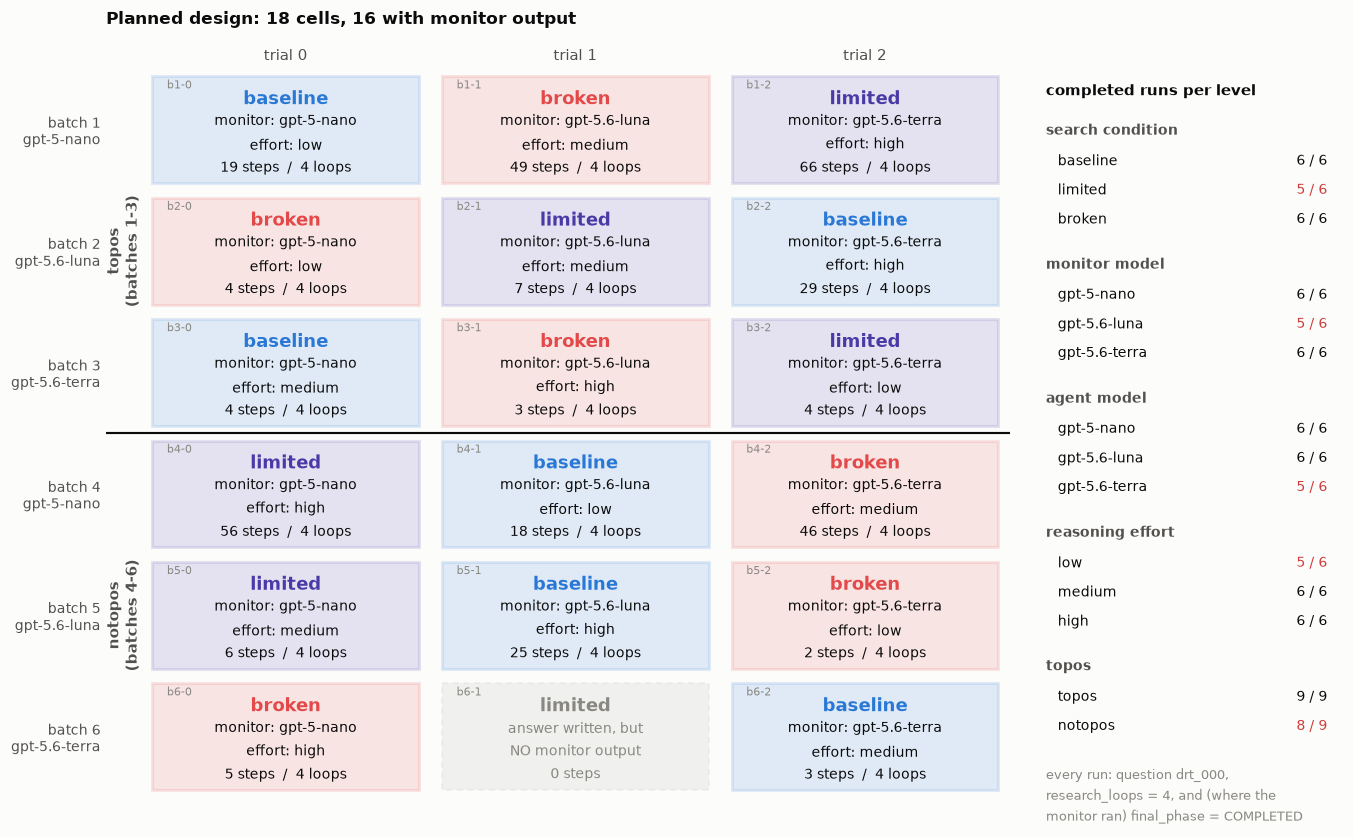

In [13]:
fig = plt.figure(figsize=(14.5, 8.6))
gs = fig.add_gridspec(1, 2, width_ratios=[3.05, 1.0], wspace=0.06)
ax, axt = fig.add_subplot(gs[0]), fig.add_subplot(gs[1])

by_cell = {(r.batch, r.trial): r for r in runs.itertuples()}
for (b, t), r in by_cell.items():
    x, y = t, b - 1
    usable = r.n_steps > 0
    c = COND_COLOR[r.condition] if usable else MUTED
    ax.add_patch(Rectangle((x + .04, y + .06), .92, .88, facecolor=c,
                           alpha=.13 if usable else .10, edgecolor=c,
                           linewidth=2 if usable else 1,
                           linestyle="-" if usable else (0, (4, 3)), zorder=2))
    ax.text(x + .5, y + .25, r.condition, ha="center", va="center", zorder=3,
            fontsize=12, fontweight="bold", color=c if usable else MUTED)
    if usable:
        lines = [f"monitor: {r.monitor_model}",
                 f"effort: {r.effort}",
                 f"{r.n_steps} steps  /  {int(r.research_loops)} loops"]
    elif r.present:
        lines = ["answer written, but", "NO monitor output", "0 steps"]
    else:
        lines = ["no results.jsonl", "(empty directory)", ""]
    ax.text(x + .5, y + .62, "\n".join(lines), ha="center", va="center", zorder=3,
            fontsize=9, color=INK if usable else MUTED, linespacing=1.7)
    ax.text(x + .09, y + .16, f"b{b}-{t}", fontsize=7.5, color=MUTED, zorder=3)

ax.axhline(3, color=INK, linewidth=1.4, zorder=4)
ax.text(-.06, 1.5, "topos\n(batches 1-3)", rotation=90, ha="center", va="center",
        fontsize=10, fontweight="bold", color=SECOND)
ax.text(-.06, 4.5, "notopos\n(batches 4-6)", rotation=90, ha="center", va="center",
        fontsize=10, fontweight="bold", color=SECOND)
ax.set_xlim(-.12, 3); ax.set_ylim(6, 0)
ax.set_xticks([.5, 1.5, 2.5]); ax.set_xticklabels([f"trial {i}" for i in range(3)],
                                                  fontsize=10, color=SECOND)
ax.xaxis.set_ticks_position("top"); ax.xaxis.set_label_position("top")
ax.set_yticks([i + .5 for i in range(6)])
ax.set_yticklabels([f"batch {i+1}\n{runs[runs.batch==i+1].agent_model.iloc[0]}"
                    for i in range(6)], fontsize=9, color=SECOND)
for s in ax.spines.values():
    s.set_visible(False)
ax.tick_params(length=0)
ax.set_title("Planned design: 18 cells, 16 with monitor output", pad=16, loc="left")

# side table: completed runs per factor level
axt.axis("off")
y = 0.98
axt.text(0, y, "completed runs per level", fontsize=10, fontweight="bold",
         va="top", color=INK); y -= 0.055
for label, col in [("search condition", "condition"), ("monitor model", "monitor_model"),
                   ("agent model", "agent_model"), ("reasoning effort", "effort"),
                   ("topos", "topos")]:
    axt.text(0, y, label, fontsize=9, fontweight="bold", va="top", color=SECOND)
    y -= 0.042
    counts = ok[col].value_counts()
    allc = runs[col].value_counts()
    for lvl in (COND_ORDER if col == "condition" else
                MODEL_ORDER if col in ("monitor_model", "agent_model") else
                EFFORTS if col == "effort" else [True, False]):
        n, N = int(counts.get(lvl, 0)), int(allc.get(lvl, 0))
        nm = {True: "topos", False: "notopos"}.get(lvl, lvl)
        axt.text(0.04, y, f"{nm}", fontsize=9, va="top", color=INK)
        axt.text(0.95, y, f"{n} / {N}", fontsize=9, va="top", ha="right",
                 color=INK if n == N else "#d03b3b")
        y -= 0.04
    y -= 0.022
axt.text(0, y, "every run: question drt_000,\nresearch_loops = 4, and (where the\nmonitor ran) final_phase = COMPLETED",
         fontsize=8.5, va="top", color=MUTED, linespacing=1.6)
plt.show()

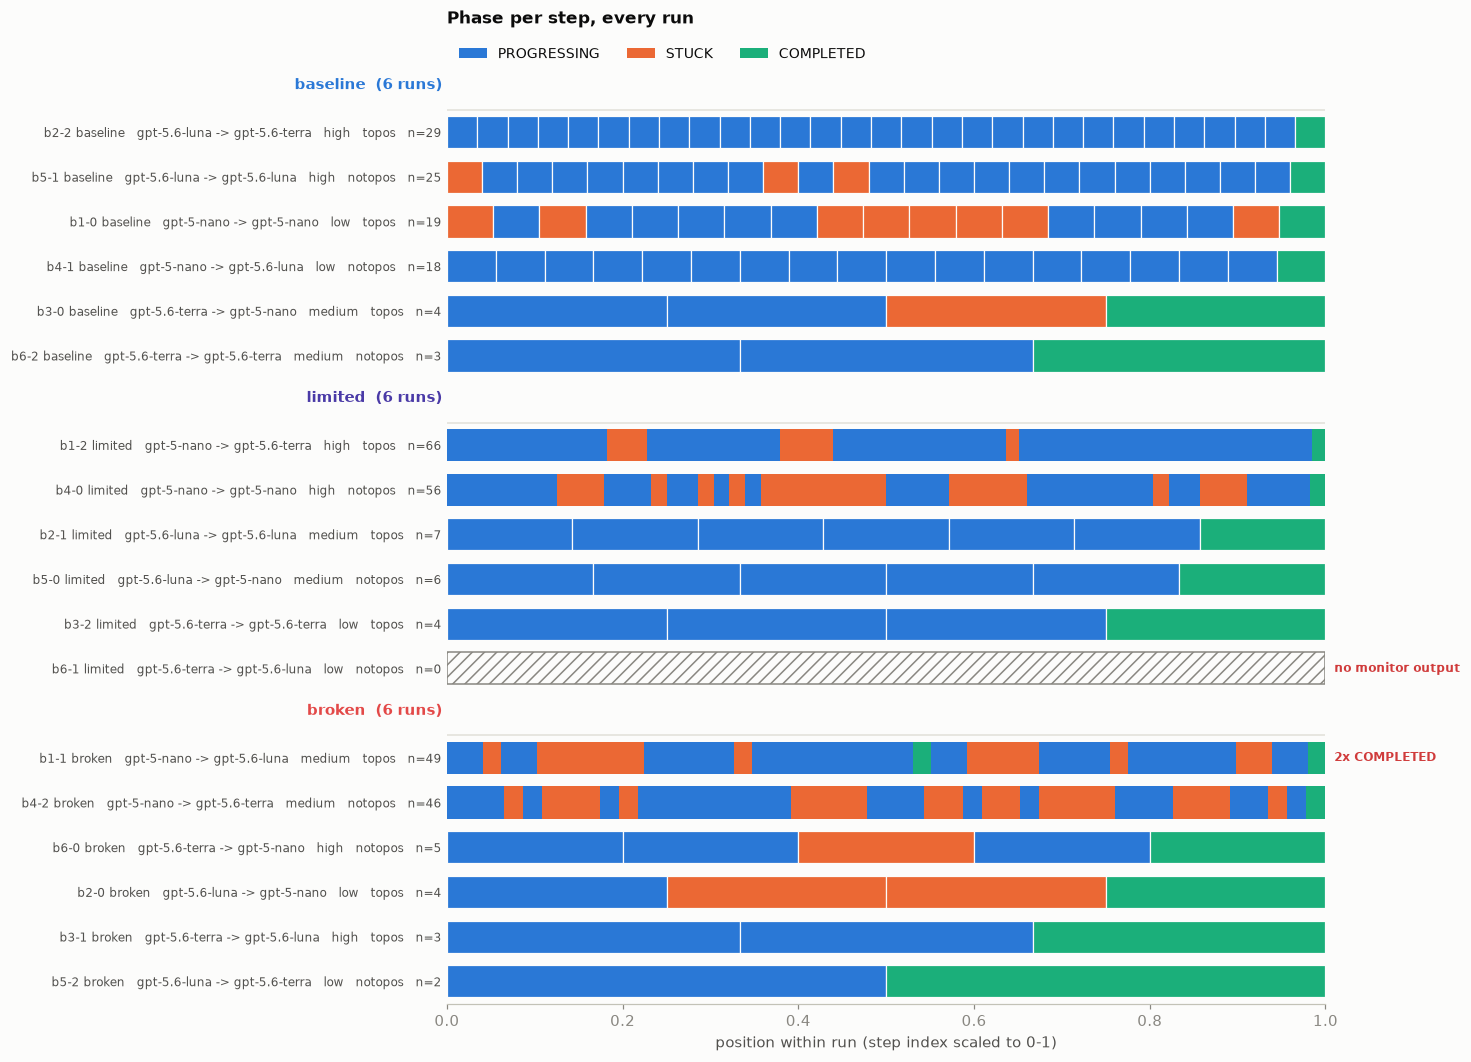

In [14]:
order = []
for cond in COND_ORDER:
    grp = runs[runs.condition == cond].sort_values("n_steps", ascending=False)
    order.append((cond, list(grp.itertuples())))

nrows = len(runs) + len(COND_ORDER)
fig, ax = plt.subplots(figsize=(13.5, 0.36 * nrows + 2.2))
y, yticks, ylabels, seps = 0, [], [], []
for cond, rows in order:
    seps.append((y - 0.5, cond, len(rows)))
    for r in rows:
        if r.n_steps > 0:
            ph = steps[steps.run == r.run].sort_values("i")
            w = 1.0 / r.n_steps
            edge = SURFACE if r.n_steps <= 30 else None
            ax.broken_barh([(i * w, w) for i in ph.i], (y - .36, .72),
                           facecolors=[PHASE_COLOR[p] for p in ph.phase],
                           edgecolor=edge, linewidth=0.8 if edge else 0, zorder=2)
            notes = []
            if r.n_completed_labels > 1:
                notes.append(f"{int(r.n_completed_labels)}x COMPLETED")
            if r.final_phase != "COMPLETED":
                notes.append(f"final_phase={r.final_phase}")
            if notes:
                ax.text(1.01, y, " | ".join(notes), va="center", fontsize=8,
                        color="#d03b3b", fontweight="bold")
        else:
            ax.broken_barh([(0, 1)], (y - .36, .72), facecolors="none",
                           edgecolor=MUTED, linewidth=1, hatch="///", zorder=2)
            ax.text(1.01, y, "no monitor output", va="center", fontsize=8,
                    color="#d03b3b", fontweight="bold")
        yticks.append(y)
        ylabels.append(f"{short(r.run)}   {r.agent_model} -> {r.monitor_model}   "
                       f"{r.effort}   {'topos' if r.topos else 'notopos'}   n={r.n_steps}")
        y += 1
    y += 1

for ypos, cond, n in seps:
    ax.axhline(ypos, color=GRID, linewidth=1, zorder=1)
    ax.text(-0.005, ypos - 0.55, f"{cond}  ({n} runs)", ha="right", va="center",
            fontsize=10, fontweight="bold", color=COND_COLOR[cond])
ax.set_yticks(yticks); ax.set_yticklabels(ylabels, fontsize=8, color=SECOND)
ax.tick_params(axis="y", length=0)
ax.set_ylim(y - 1.5, -1.2)
ax.set_xlim(0, 1); ax.set_xlabel("position within run (step index scaled to 0-1)")
ax.spines["left"].set_visible(False)
ax.set_title("Phase per step, every run", loc="left", pad=36)
ax.legend(handles=[Patch(facecolor=PHASE_COLOR[p], label=p) for p in PHASES],
          loc="lower left", bbox_to_anchor=(0, 1.005), ncol=3, frameon=False, fontsize=9)
plt.tight_layout(); plt.show()

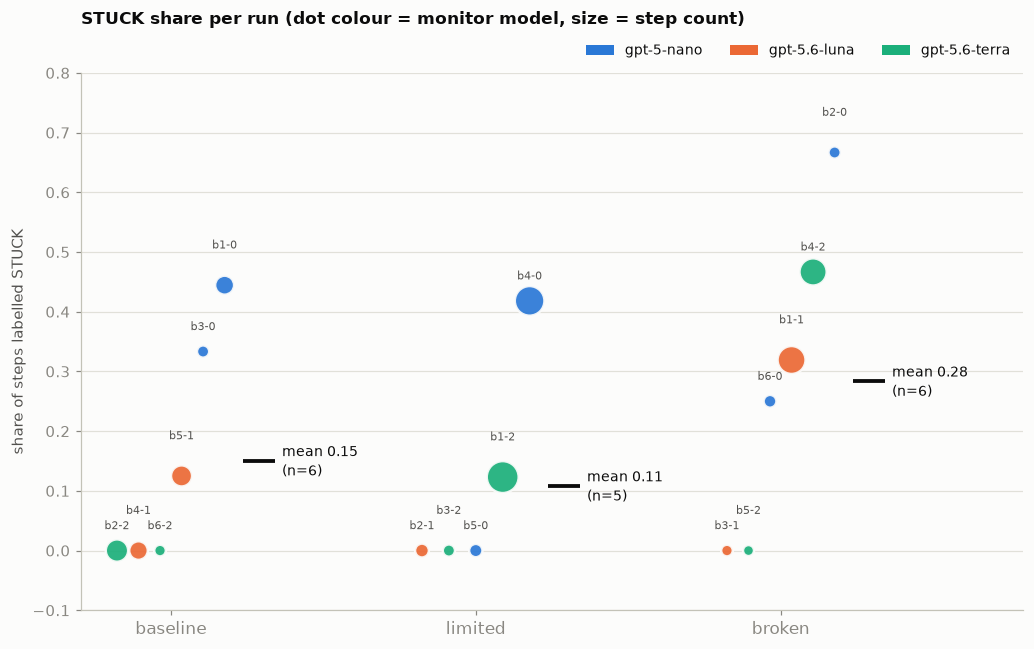

           runs  mean_stuck  runs_with_zero_stuck
condition                                        
baseline      6    0.150463                     3
limited       5    0.108252                     3
broken        6    0.283747                     2


In [15]:
d = ok.dropna(subset=["stuck_share"])
fig, ax = plt.subplots(figsize=(9.5, 6))
XSTEP = 1.7
for k_, cond in enumerate(COND_ORDER):
    i = k_ * XSTEP
    # spread deterministically by rank instead of jittering, so tied runs
    # (several sit exactly at 0.00) stay readable
    g = d[d.condition == cond].sort_values("stuck_share")
    off = np.linspace(-.30, .30, len(g)) if len(g) > 1 else np.array([0.0])
    ax.scatter(i + off, g.stuck_share, s=40 + g.n_steps * 6,
               c=[MODEL_COLOR[m] for m in g.monitor_model],
               edgecolor=SURFACE, linewidth=1.6, zorder=3, alpha=.92)
    for k, (x, yv, r) in enumerate(zip(i + off, g.stuck_share, g.itertuples())):
        ax.annotate(short(r.run).split()[0], (x, yv), textcoords="offset points",
                    xytext=(0, 14 + 10 * (k % 2)), ha="center", fontsize=7.5,
                    color=SECOND, zorder=4)
    # the mean sits just outside the dot cloud so it never crosses a run label
    m = g.stuck_share.mean()
    ax.hlines(m, i + .40, i + .58, color=INK, linewidth=2.5, zorder=5)
    ax.text(i + .62, m, f"mean {m:.2f}\n(n={len(g)})", ha="left", va="center",
            fontsize=9, color=INK, zorder=6, linespacing=1.4)
tidy(ax)
ax.set_xticks([k_ * XSTEP for k_ in range(3)])
ax.set_xticklabels(COND_ORDER, fontsize=11)
ax.set_xlim(-.5, 2 * XSTEP + 1.35); ax.set_ylim(-.10, .80)
ax.set_ylabel("share of steps labelled STUCK")
ax.set_title("STUCK share per run (dot colour = monitor model, size = step count)",
             loc="left", pad=32)
ax.legend(handles=[Patch(facecolor=MODEL_COLOR[m], label=m) for m in MODEL_ORDER],
          loc="lower right", bbox_to_anchor=(1, 1.005), ncol=3, frameon=False,
          fontsize=9)
plt.tight_layout(); plt.show()

print(d.groupby("condition", observed=True)
       .agg(runs=("run", "size"), mean_stuck=("stuck_share", "mean"),
            runs_with_zero_stuck=("n_stuck", lambda s: int((s == 0).sum()))))

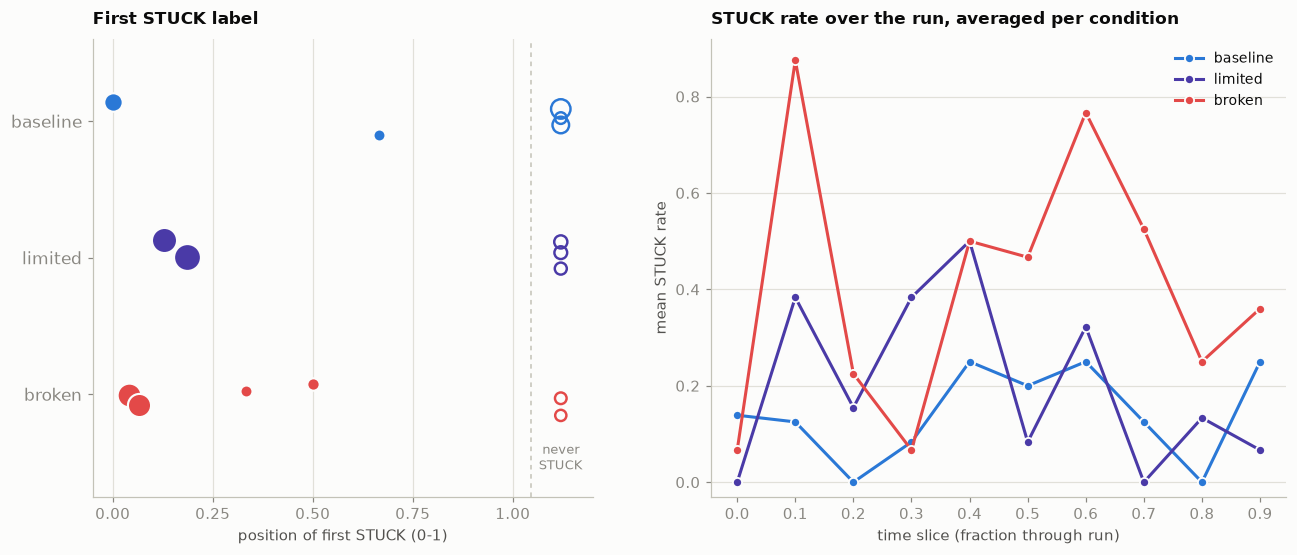

In [16]:
fig, (axl, axr) = plt.subplots(1, 2, figsize=(14, 5.4),
                               gridspec_kw={"width_ratios": [1, 1.15], "wspace": .22})
rng = np.random.default_rng(3)
NEVER = 1.12
for i, cond in enumerate(COND_ORDER):
    for r in ok[ok.condition == cond].itertuples():
        b = body[(body.run == r.run)].sort_values("i")
        st = b[b.phase == "STUCK"]
        yj = i + rng.uniform(-.17, .17)
        if len(st):
            axl.scatter(st.pos.iloc[0], yj, s=46 + r.n_steps * 4,
                        color=COND_COLOR[cond], edgecolor=SURFACE, linewidth=1.4, zorder=3)
        else:
            axl.scatter(NEVER, yj, s=46 + r.n_steps * 4, facecolor="none",
                        edgecolor=COND_COLOR[cond], linewidth=1.6, zorder=3)
axl.axvline(1.045, color=AXIS, linewidth=1, linestyle=(0, (3, 3)))
axl.text(NEVER, 2.55, "never\nSTUCK", ha="center", fontsize=8.5, color=MUTED)
tidy(axl, "x")
axl.set_yticks(range(3)); axl.set_yticklabels(COND_ORDER, fontsize=11)
axl.set_ylim(2.75, -.6); axl.set_xlim(-.05, 1.2)
axl.set_xticks([0, .25, .5, .75, 1])
axl.set_xlabel("position of first STUCK (0-1)")
axl.set_title("First STUCK label", loc="left", pad=10)

NS = 10
rows = []
for r in ok.itertuples():
    b = body[body.run == r.run].sort_values("i")
    if len(b) == 0:
        continue
    pos = np.arange(len(b)) / max(len(b) - 1, 1)
    sl = np.minimum((pos * NS).astype(int), NS - 1)
    for s in range(NS):
        m = sl == s
        if m.any():
            rows.append(dict(run=r.run, condition=r.condition, slice=s,
                             stuck=(b.phase.values[m] == "STUCK").mean()))
sl_df = pd.DataFrame(rows)
for cond in COND_ORDER:
    g = sl_df[sl_df.condition == cond].groupby("slice").stuck.mean().reindex(range(NS))
    axr.plot(g.index, g.values, color=COND_COLOR[cond], marker="o", markersize=6,
             markeredgecolor=SURFACE, markeredgewidth=1.2, label=cond, zorder=3)
tidy(axr)
axr.set_xticks(range(NS)); axr.set_xticklabels([f"{i/NS:.1f}" for i in range(NS)])
axr.set_xlabel("time slice (fraction through run)")
axr.set_ylabel("mean STUCK rate")
axr.set_ylim(-.03, None)
axr.set_title("STUCK rate over the run, averaged per condition", loc="left", pad=10)
axr.legend(frameon=False, fontsize=9)
plt.show()

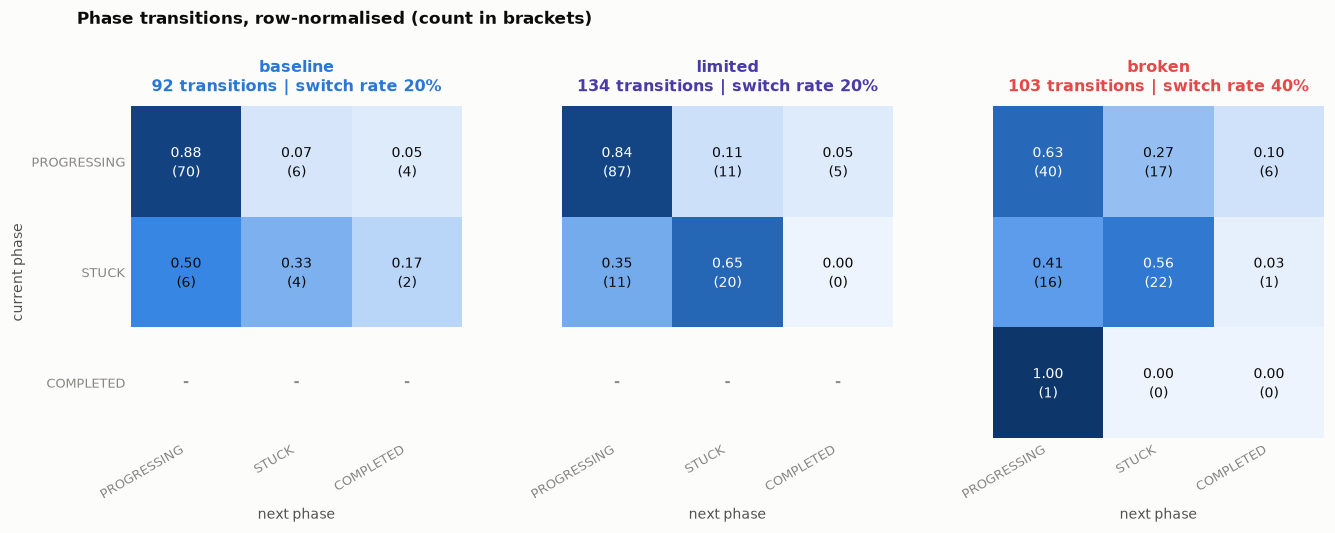

In [17]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4.9), gridspec_kw={"wspace": .30})
cmap = mpl.colors.LinearSegmentedColormap.from_list(
    "seq_blue", ["#eef4fd", "#9ec5f4", "#3987e5", "#184f95", "#0d366b"])
for axp, cond in zip(axes, COND_ORDER):
    t = steps[(steps.condition == cond) & steps.next_phase.notna()]
    M = pd.crosstab(t.phase, t.next_phase).reindex(index=PHASES, columns=PHASES).fillna(0)
    N = M.div(M.sum(axis=1).replace(0, np.nan), axis=0)
    axp.imshow(N.values, cmap=cmap, vmin=0, vmax=1)
    for i in range(3):
        for j in range(3):
            v, c = N.values[i, j], int(M.values[i, j])
            if np.isnan(v):
                axp.text(j, i, "-", ha="center", va="center", color=MUTED, fontsize=11)
            else:
                axp.text(j, i, f"{v:.2f}\n({c})", ha="center", va="center", fontsize=9,
                         color="#ffffff" if v > .55 else INK, linespacing=1.4)
    sw = (t.phase.values != t.next_phase.values).mean() if len(t) else np.nan
    axp.set_title(f"{cond}\n{len(t)} transitions | switch rate {sw:.0%}",
                  color=COND_COLOR[cond], pad=10, fontsize=10.5)
    axp.set_xticks(range(3)); axp.set_xticklabels(PHASES, rotation=30, ha="right", fontsize=8.5)
    axp.set_yticks(range(3)); axp.set_yticklabels(PHASES if cond == COND_ORDER[0] else [],
                                                  fontsize=8.5)
    axp.set_xlabel("next phase", fontsize=9)
    axp.tick_params(length=0)
    for s in axp.spines.values():
        s.set_visible(False)
axes[0].set_ylabel("current phase", fontsize=9)
fig.suptitle("Phase transitions, row-normalised (count in brackets)", x=.09, ha="left",
             fontweight="bold", fontsize=11)
plt.show()

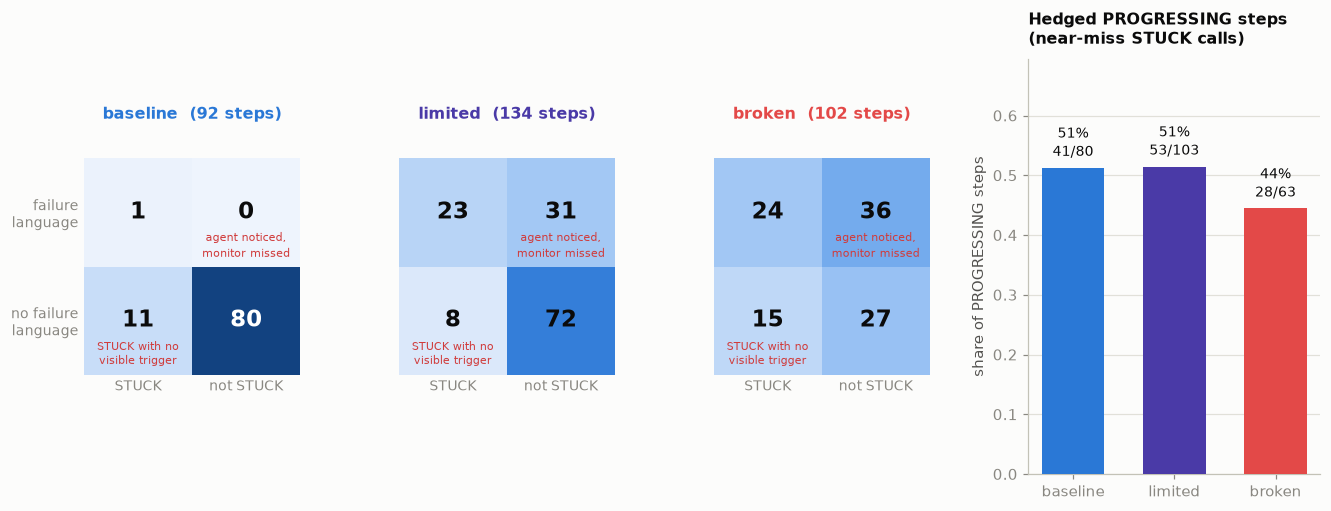

,agent_noticed_monitor_missed,both,stuck_no_trigger,neither
condition,,,,
baseline,0,1,11,80
limited,31,23,8,72
broken,36,24,15,27


In [18]:
fig = plt.figure(figsize=(14.5, 4.9))
gs = fig.add_gridspec(1, 4, width_ratios=[1, 1, 1, 1.35], wspace=.42)
cmap = mpl.colors.LinearSegmentedColormap.from_list(
    "seq_blue", ["#eef4fd", "#9ec5f4", "#3987e5", "#184f95", "#0d366b"])
tab_rows = []
for k, cond in enumerate(COND_ORDER):
    axp = fig.add_subplot(gs[k])
    b = body[body.condition == cond]
    M = np.array([[((b.fail_lang) & (b.phase == "STUCK")).sum(),
                   ((b.fail_lang) & (b.phase != "STUCK")).sum()],
                  [((~b.fail_lang) & (b.phase == "STUCK")).sum(),
                   ((~b.fail_lang) & (b.phase != "STUCK")).sum()]], dtype=float)
    axp.imshow(M / max(M.sum(), 1), cmap=cmap, vmin=0, vmax=1)
    for i in range(2):
        for j in range(2):
            axp.text(j, i, f"{int(M[i, j])}", ha="center", va="center", fontsize=15,
                     fontweight="bold",
                     color="#ffffff" if M[i, j] / max(M.sum(), 1) > .55 else INK)
    axp.text(1, .30, "agent noticed,\nmonitor missed", fontsize=7.5, ha="center",
             va="center", color="#d03b3b", linespacing=1.3)
    axp.text(0, 1.30, "STUCK with no\nvisible trigger", fontsize=7.5, ha="center",
             va="center", color="#d03b3b", linespacing=1.3)
    axp.set_xticks([0, 1]); axp.set_xticklabels(["STUCK", "not STUCK"], fontsize=9)
    axp.set_yticks([0, 1]); axp.set_yticklabels(
        ["failure\nlanguage", "no failure\nlanguage"] if k == 0 else [], fontsize=9)
    axp.set_title(f"{cond}  ({int(M.sum())} steps)", color=COND_COLOR[cond], pad=26,
                  fontsize=10.5)
    axp.tick_params(length=0)
    for s in axp.spines.values():
        s.set_visible(False)
    tab_rows.append(dict(condition=cond, agent_noticed_monitor_missed=int(M[0, 1]),
                         both=int(M[0, 0]), stuck_no_trigger=int(M[1, 0]),
                         neither=int(M[1, 1])))

axh = fig.add_subplot(gs[3])
prog = body[body.phase == "PROGRESSING"]
g = prog.groupby("condition", observed=True).hedged.agg(["mean", "sum", "size"])
g = g.reindex(COND_ORDER)
axh.bar(range(3), g["mean"], color=[COND_COLOR[c] for c in COND_ORDER], width=.62, zorder=3)
for i, (m, s, n) in enumerate(zip(g["mean"], g["sum"], g["size"])):
    axh.text(i, m + .02, f"{m:.0%}\n{int(s)}/{int(n)}", ha="center", fontsize=9,
             color=INK, linespacing=1.4)
tidy(axh)
axh.set_xticks(range(3)); axh.set_xticklabels(COND_ORDER, fontsize=10)
axh.set_ylim(0, min(1, g["mean"].max() + .18))
axh.set_ylabel("share of PROGRESSING steps")
axh.set_title("Hedged PROGRESSING steps\n(near-miss STUCK calls)", loc="left",
              pad=10, fontsize=10.5)
plt.show()
pd.DataFrame(tab_rows).set_index("condition")

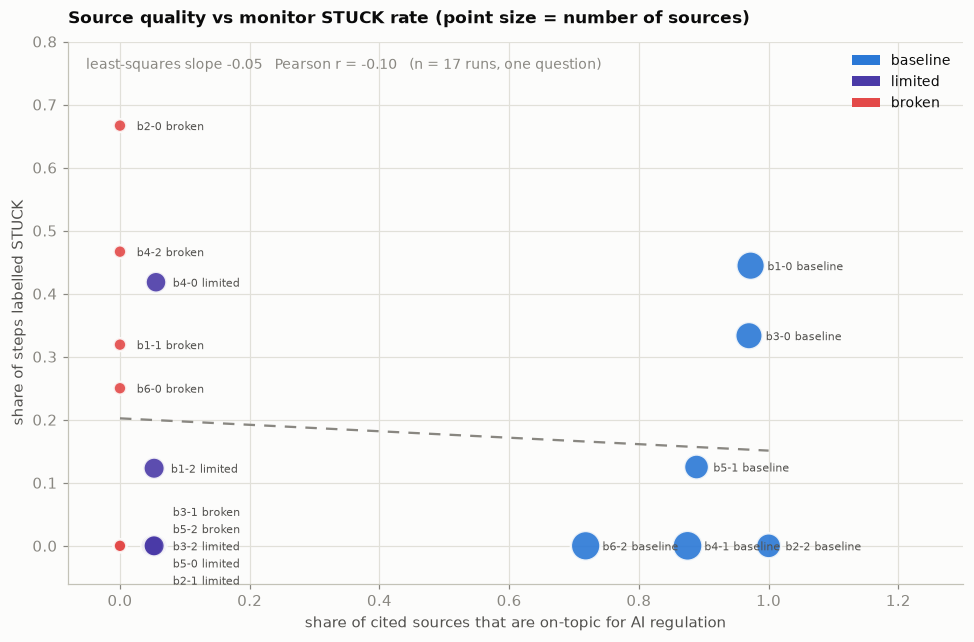

           sources  on_topic_share
condition                         
baseline       202        0.896040
broken          30        0.000000
limited        113        0.053097


In [19]:
d = ok.dropna(subset=["stuck_share", "on_topic_share"])
fig, ax = plt.subplots(figsize=(10.5, 6.4))
for cond in COND_ORDER:
    g = d[d.condition == cond]
    ax.scatter(g.on_topic_share, g.stuck_share, s=25 + g.n_sources * 9,
               color=COND_COLOR[cond], edgecolor=SURFACE, linewidth=1.6,
               alpha=.9, zorder=3)
# several runs land on identical coordinates; stack their labels instead of
# printing them on top of one another
# the degraded runs pile up in the bottom-left corner, so near-coincident
# points get one shared label listing their runs rather than a stack of
# overlapping ones
clusters = []
for r in d.sort_values(["stuck_share", "on_topic_share", "run"]).itertuples():
    p = (r.on_topic_share, r.stuck_share)
    for cl in clusters:
        if abs(p[0] - cl["x"]) < .10 and abs(p[1] - cl["y"]) < .025:
            cl["runs"].append(short(r.run)); cl["x"] = max(cl["x"], p[0])
            break
    else:
        clusters.append(dict(x=p[0], y=p[1], runs=[short(r.run)]))
for cl in clusters:
    ax.annotate("\n".join(cl["runs"]), (cl["x"], cl["y"]), textcoords="offset points",
                xytext=(11, 0), va="center", fontsize=7.5, color=SECOND, zorder=4,
                linespacing=1.5)
x, yv = d.on_topic_share.values, d.stuck_share.values
if len(d) > 2:
    b1, b0 = np.polyfit(x, yv, 1)
    xs = np.linspace(0, 1, 50)
    ax.plot(xs, b0 + b1 * xs, color=MUTED, linewidth=1.5, linestyle=(0, (5, 4)), zorder=2)
    ax.text(.02, .97, f"least-squares slope {b1:+.2f}   Pearson r = {np.corrcoef(x, yv)[0,1]:+.2f}"
            f"   (n = {len(d)} runs, one question)", transform=ax.transAxes,
            fontsize=9, color=MUTED, va="top")
tidy(ax, "both")
ax.set_xlabel("share of cited sources that are on-topic for AI regulation")
ax.set_ylabel("share of steps labelled STUCK")
ax.set_xlim(-.08, 1.30); ax.set_ylim(-.06, .80)
ax.set_title("Source quality vs monitor STUCK rate (point size = number of sources)",
             loc="left", pad=12)
ax.legend(handles=[Patch(facecolor=COND_COLOR[c_], label=c_) for c_ in COND_ORDER],
          frameon=False, fontsize=9, loc="upper right")
plt.show()

print(sources.groupby("condition", observed=True)
      .agg(sources=("on_topic", "size"), on_topic_share=("on_topic", "mean")))

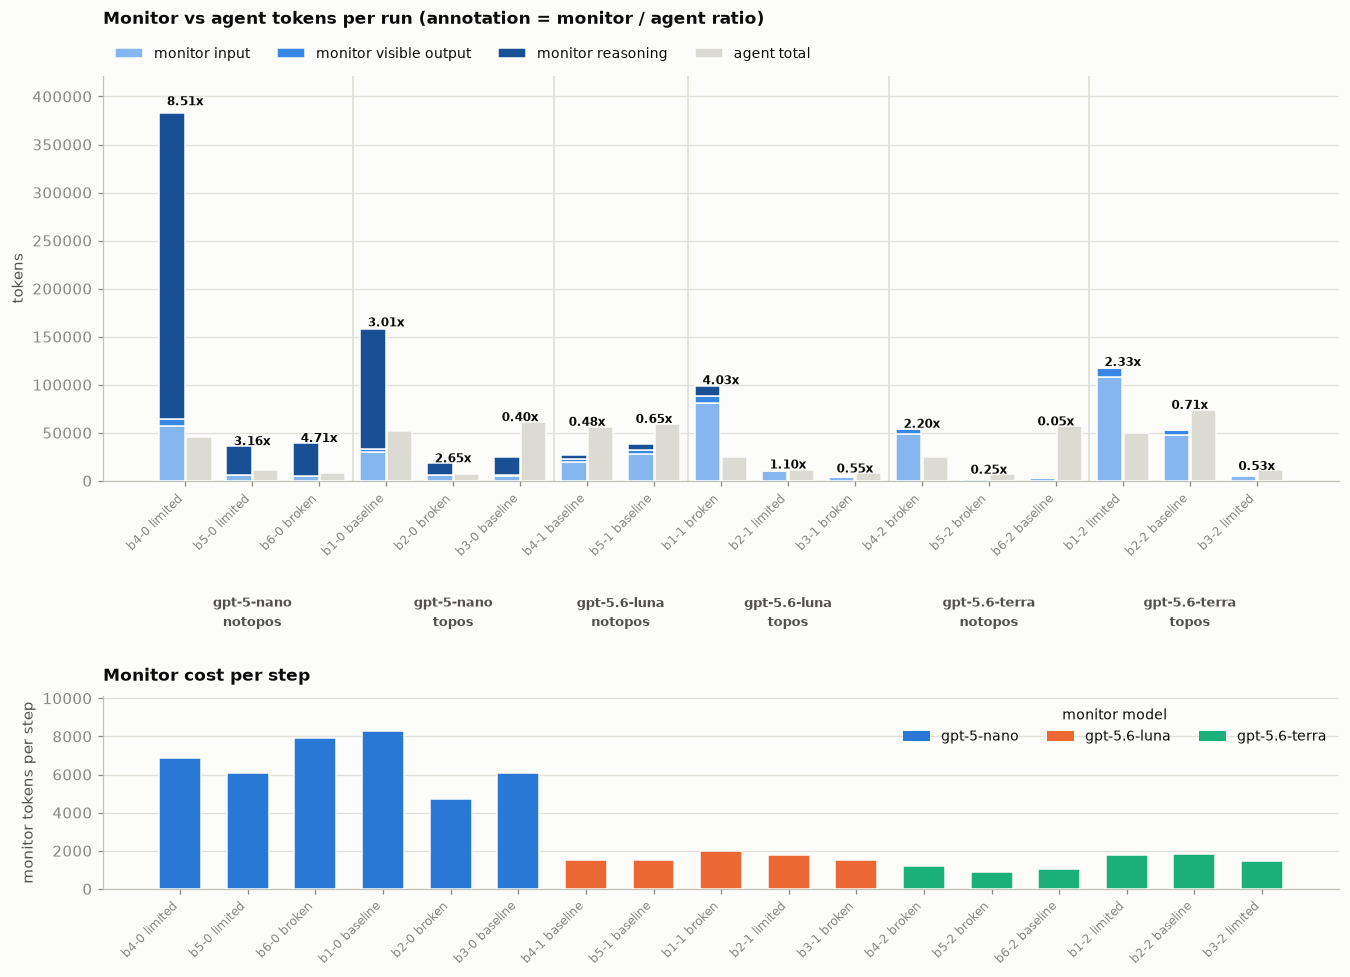

,monitor_model,topos,n_steps,monitor_input,monitor_visible_output,monitor_reasoning,monitor_total,agent_total,monitor_agent_ratio,monitor_per_step
run,,,,,,,,,,
batch4-0-limited-gpt-5-nano-gpt-5-nano-high-notopos-20260917-114809,gpt-5-nano,False,56,57485,7215,318528,383228,45056,8.505593,6843.357143
batch5-0-limited-gpt-5.6-luna-gpt-5-nano-medium-notopos-20260917-101449,gpt-5-nano,False,6,5538,762,30080,36380,11523,3.157164,6063.333333
batch6-0-broken-gpt-5.6-terra-gpt-5-nano-high-notopos-20260917-102040,gpt-5-nano,False,5,4487,596,34496,39579,8397,4.713469,7915.800000
batch1-0-baseline-gpt-5-nano-gpt-5-nano-low-topos-20260914-120239,gpt-5-nano,True,19,30370,2915,124288,157573,52327,3.011313,8293.315789
batch2-0-broken-gpt-5.6-luna-gpt-5-nano-low-topos-20260916-100630,gpt-5-nano,True,4,5531,500,12864,18895,7120,2.653792,4723.750000
batch3-0-baseline-gpt-5.6-terra-gpt-5-nano-medium-topos-20260916-101846,gpt-5-nano,True,4,5217,528,18624,24369,60925,0.399984,6092.250000
batch4-1-baseline-gpt-5-nano-gpt-5.6-luna-low-notopos-20260917-094216,gpt-5.6-luna,False,18,19476,2937,4431,26844,56127,0.478272,1491.333333
batch5-1-baseline-gpt-5.6-luna-gpt-5.6-luna-high-notopos-20260917-101449,gpt-5.6-luna,False,25,28307,4227,5594,38128,59037,0.645832,1525.120000
batch1-1-broken-gpt-5-nano-gpt-5.6-luna-medium-topos-20260914-112051,gpt-5.6-luna,True,49,81043,7421,10102,98566,24450,4.031329,2011.551020


In [20]:
d = ok.sort_values(["monitor_model", "topos", "batch", "trial"]).reset_index(drop=True)
fig, (ax, ax2) = plt.subplots(2, 1, figsize=(14.5, 9.6),
                              gridspec_kw={"height_ratios": [2.1, 1], "hspace": .72})
xs = np.arange(len(d)); w = .38
bot = np.zeros(len(d))
for part in ["input", "visible_output", "reasoning"]:
    v = d[f"monitor_{part}"].values
    ax.bar(xs - w / 2 - .01, v, w, bottom=bot, color=TOKEN_COLOR[part], zorder=3,
           label=f"monitor {part.replace('_', ' ')}", edgecolor=SURFACE, linewidth=1)
    bot += v
ax.bar(xs + w / 2 + .01, d.agent_total.values, w, color="#dbdad3", edgecolor=SURFACE,
       linewidth=1, zorder=3, label="agent total")
for i, r in enumerate(d.itertuples()):
    ax.text(i, max(bot[i], r.agent_total) * 1.02, f"{r.monitor_agent_ratio:.2f}x",
            ha="center", fontsize=8, color=INK, fontweight="bold")
# group separators by (monitor model, topos)
key = list(zip(d.monitor_model, d.topos))
for i in range(1, len(d)):
    if key[i] != key[i - 1]:
        ax.axvline(i - .5, color=GRID, linewidth=1.2, zorder=1)
for k in dict.fromkeys(key):
    idx = [i for i, kk in enumerate(key) if kk == k]
    ax.annotate(f"{k[0]}\n{'topos' if k[1] else 'notopos'}",
                xy=(np.mean(idx), 0), xycoords=("data", "axes fraction"),
                xytext=(0, -74), textcoords="offset points", ha="center", va="top",
                fontsize=8.5, color=SECOND, fontweight="bold", linespacing=1.5,
                annotation_clip=False)
tidy(ax)
ax.set_xticks(xs); ax.set_xticklabels([short(r) for r in d.run], rotation=45,
                                      ha="right", fontsize=8)
ax.tick_params(axis="x", pad=4)
ax.set_ylabel("tokens")
ax.set_ylim(0, max(bot.max(), d.agent_total.max()) * 1.10)
ax.set_title("Monitor vs agent tokens per run (annotation = monitor / agent ratio)",
             loc="left", pad=34)
ax.legend(frameon=False, fontsize=9, ncol=4, loc="lower left",
          bbox_to_anchor=(0, 1.005))

per = (d.monitor_total / d.n_steps).values
ax2.bar(xs, per, .62, color=[MODEL_COLOR[m] for m in d.monitor_model], zorder=3,
        edgecolor=SURFACE, linewidth=1)
tidy(ax2)
ax2.set_xticks(xs); ax2.set_xticklabels([short(r) for r in d.run], rotation=45,
                                        ha="right", fontsize=8)
ax2.set_ylabel("monitor tokens per step")
ax2.set_title("Monitor cost per step", loc="left", pad=10)
ax2.set_ylim(0, per.max() * 1.22)
ax2.legend(handles=[Patch(facecolor=MODEL_COLOR[m], label=m) for m in MODEL_ORDER],
           frameon=False, fontsize=9, ncol=3, loc="upper right", title="monitor model",
           title_fontsize=9)
plt.show()

d.assign(monitor_per_step=per)[
    ["run", "monitor_model", "topos", "n_steps", "monitor_input", "monitor_visible_output",
     "monitor_reasoning", "monitor_total", "agent_total", "monitor_agent_ratio",
     "monitor_per_step"]].set_index("run")